# XGBoost for Regression is a supervised machine learning algorithm that predicts continuous numerical values (e.g., house prices, sales, temperature, demand). It uses gradient-boosted decision trees to minimize prediction error.

# How it works
Builds an initial decision tree.

Calculates the prediction errors (residuals).

Trains a new tree to predict those residuals.

Repeats the process, adding trees sequentially.

The final prediction is the sum of predictions from all trees.

# Advantages
High predictive accuracy.

Handles non-linear relationships well.

Works with missing values.

Built-in regularization reduces overfitting.

Supports parallel processing for faster training.

Provides feature importance scores.

# Common Hyperparameter

| Parameter          | Description                                |
| ------------------ | ------------------------------------------ |
| `n_estimators`     | Number of trees                            |
| `learning_rate`    | Step size for each tree                    |
| `max_depth`        | Maximum depth of each tree                 |
| `subsample`        | Fraction of training samples used per tree |
| `colsample_bytree` | Fraction of features used per tree         |
| `min_child_weight` | Minimum weight required in a leaf node     |
| `gamma`            | Minimum loss reduction needed for a split  |
| `reg_alpha`        | L1 regularization                          |
| `reg_lambda`       | L2 regularization                          |


# Python Example

In [ ]:
from xgboost import XGBRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np # Import numpy

# Load data
X, y = fetch_california_housing(return_X_y=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    objective='reg:squarederror',
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred) # Calculate MSE first
rmse = np.sqrt(mse) # Then take the square root for RMSE
print("RMSE:", rmse)

RMSE: 0.4750963523653759


# When to Use XGBoost

Use XGBoost when:

Your dataset contains complex, non-linear relationships.

You need high predictive performance.

Your data is tabular (structured).

You want robust handling of missing values and outliers.

# Avoid XGBoost when:

You need a highly interpretable model (consider linear regression or a simple decision tree).

Your dataset is extremely small, where simpler models may generalize better.

# step by step Calculation

# Example Dataset

Suppose we want to predict House Price from House Size.

| House Size (sq ft) | Actual Price |
| ------------------ | ------------ |
| 1                  | 10           |
| 2                  | 20           |
| 3                  | 30           |
| 4                  | 40           |


# Step 1: Initial Prediction

Unlike Linear Regression, XGBoost starts with a simple prediction.

For regression, it usually predicts the mean of all target values.

Mean=10+20+30+40/4=25

So initially every house is predicted as 25.

| Size | Actual | Prediction |
| ---- | ------ | ---------- |
| 1    | 10     | 25         |
| 2    | 20     | 25         |
| 3    | 30     | 25         |
| 4    | 40     | 25         |


# Step 2: Calculate Residuals (Errors)

Residual

Residual=Actual−Prediction

| Size | Actual | Prediction | Residual |
| ---- | ------ | ---------- | -------- |
| 1    | 10     | 25         | -15      |
| 2    | 20     | 25         | -5       |
| 3    | 30     | 25         | 5        |
| 4    | 40     | 25         | 15       |

These residuals are what the first tree tries to learn.



# Step 3: Build First Decision Tree

Instead of predicting prices, Tree 1 predicts the residuals.

A simple tree could be

          Size < 2.5?
          /        \
      -10          +10

Why?

For left side

Residuals

-15

-5

Average

2
−15+(−5)
	​

=−10

Right side

Residuals

5

15

Average

2
5+15
	​

=10

So Tree 1 predicts

| Size | Tree Prediction |
| ---- | --------------- |
| 1    | -10             |
| 2    | -10             |
| 3    | 10              |
| 4    | 10              |


# Step 4: Apply Learning Rate

Suppose learning rate

η=0.3

Instead of adding the full tree prediction, XGBoost adds only 30%.

Updated prediction

NewPrediction=OldPrediction+0.3×TreePrediction

For House 1

Old Prediction

25

Tree says

-10

Update

25+0.3(−10)=22

House 2

25+0.3(−10)=22

House 3

25+0.3(10)=28

House 4

25+0.3(10)=28

New predictions

| Size | Prediction |
| ---- | ---------- |
| 1    | 22         |
| 2    | 22         |
| 3    | 28         |
| 4    | 28         |




# Step 5: Compute New Residuals

Residual

Actual−Prediction

| Size | Actual | Prediction | Residual |
| ---- | ------ | ---------- | -------- |
| 1    | 10     | 22         | -12      |
| 2    | 20     | 22         | -2       |
| 3    | 30     | 28         | 2        |
| 4    | 40     | 28         | 12       |

Notice that the errors have become smaller:

Earlier: -15, -5, 5, 15

Now: -12, -2, 2, 12

# Step 6: Train Tree 2

Tree 2 learns these new residuals.

Suppose it again predicts

Left = -7
Right = +7

After applying the learning rate

Left

0.3×(−7)=−2.1

Right

0.3×7=2.1

Updated prediction

| Size | Old Prediction | Tree2 Update | New Prediction |
| ---- | -------------- | ------------ | -------------- |
| 1    | 22             | -2.1         | 19.9           |
| 2    | 22             | -2.1         | 19.9           |
| 3    | 28             | 2.1          | 30.1           |
| 4    | 28             | 2.1          | 30.1           |


# Step 7: Repeat

Again compute residuals.

Train another tree.

Update predictions.

Repeat until reaching n_estimators trees or until the improvement becomes negligible.

# Final Prediction Formula

After all trees are trained,

Prediction=BasePrediction+ηT1+ηT2+ηT3+⋯

​where:

BasePrediction = mean of the target values

T1,T2,… = predictions from each tree

η = learning rat

# For classification



# Example Dataset

Suppose we want to predict whether a student will Pass (1) or Fail (0).

| Hours Studied | Actual |
| ------------- | ------ |
| 1             | 0      |
| 2             | 0      |
| 3             | 1      |
| 4             | 1      |


# Step 1: Initial Prediction

For binary classification, XGBoost starts with a base score.

By default,

p=0.5

So every student has a 50% chance of passing.

| Hours | Actual | Probability |
| ----- | ------ | ----------- |
| 1     | 0      | 0.5         |
| 2     | 0      | 0.5         |
| 3     | 1      | 0.5         |
| 4     | 1      | 0.5         |


# Step 2: Convert Probability to Log-Odds

XGBoost works internally with log-odds instead of probabilities.

Formula

LogOdds=log(p-1/p)

Since

p=0.5

log(0.5/0.5)=0

So the initial prediction for every sample is:

| Hours | Log-Odds |
| ----- | -------- |
| 1     | 0        |
| 2     | 0        |
| 3     | 0        |
| 4     | 0        |


# Step 3: Calculate Gradient (Pseudo-Residual)

For binary classification,

Gradient=y−p
	​


where:

y = actual class (0 or 1)

p = predicted probability

For each student:

| Hours | Actual | Probability | Gradient |
| ----- | ------ | ----------- | -------- |
| 1     | 0      | 0.5         | -0.5     |
| 2     | 0      | 0.5         | -0.5     |
| 3     | 1      | 0.5         | 0.5      |
| 4     | 1      | 0.5         | 0.5      |

Interpretation:

Negative gradient → predicted probability is too high for class 0, so reduce it.

Positive gradient → predicted probability is too low for class 1, so increase it.

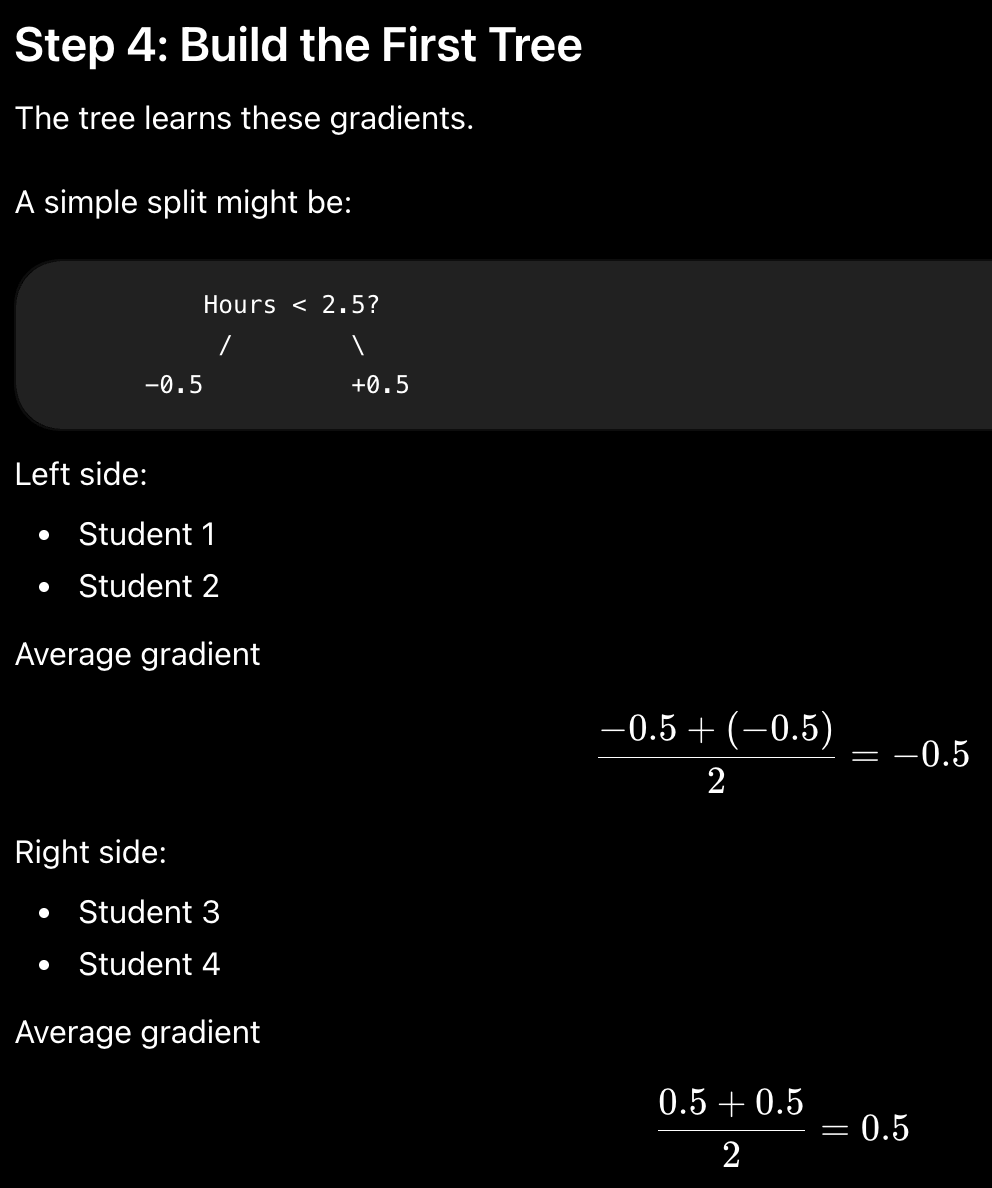

# Step 5: Apply Learning Rate

Suppose

η=0.3

Update log-odds:

For the left side:

0+0.3(−0.5)=−0.15

For the right side:

0+0.3(0.5)=0.15

# Step 6: Convert Back to Probability

Use the sigmoid function:

p=1/1+e^-z
	​


where z is the updated log-odds.

Left Side

z=−0.15

p=1/1+e^0.15 ≈0.462

Right Side

z=0.15
p=1/1+e−0.15≈0.538

New predictions:

| Hours | Probability |
| ----- | ----------- |
| 1     | 0.462       |
| 2     | 0.462       |
| 3     | 0.538       |
| 4     | 0.538       |

Notice:

The probabilities for the students who actually failed have gone down.

The probabilities for the students who actually passed have gone up.

# Step 7: Calculate New Gradients

Now compute:

Gradient=y−p

| Hours | Actual | Probability | Gradient |
| ----- | ------ | ----------- | -------- |
| 1     | 0      | 0.462       | -0.462   |
| 2     | 0      | 0.462       | -0.462   |
| 3     | 1      | 0.538       | 0.462    |
| 4     | 1      | 0.538       | 0.462    |

The gradients are now smaller than before (from ±0.5 to ±0.462), meaning the model has improved.


# Step 8: Train Tree 2

Tree 2 learns these new gradients.

It again adjusts the log-odds.

The probabilities become even closer to:

0.35
0.25
0.75
0.85

(Exact values depend on the learned tree.)

# Step 9: Repeat

Repeat the process:

Compute gradients.
Build a tree.
Update log-odds.
Convert to probabilities.

Each new tree corrects the mistakes made by the previous trees.

# Final Prediction

After all trees are built:

If the final probability is ≥ 0.5, predict Class 1 (Pass).
If the final probability is < 0.5, predict Class 0 (Fail).